In [ ]:
# import libraries
import numpy as np
from numpy import median
from scipy import stats
import pandas as pd
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt
%matplotlib inline
from collections import Counter
import random as rn
from functools import reduce

# Import and suppress warnings
import warnings
warnings.filterwarnings('ignore')
import os

In [ ]:
# Read the file
df3 = pd.read_csv('CleanF.csv')

In [ ]:
# Shape of data
df3.shape

(23139, 31)

In [ ]:
df3

,Unnamed: 0,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,0,8,0,1,6,4,0,5,1
1,1,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,0,8,0,1,6,4,0,5,1
2,2,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,0,8,0,1,6,4,0,5,1
3,3,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,0,8,0,1,6,4,0,5,1
4,4,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,4,Female,...,3,3,21,2,3,5,0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23134,23134,60,Travel_Rarely,370,Research & Development,1,4,Life Sciences,3,Male,...,3,1,19,2,4,1,0,0,0,0
23135,23135,60,Travel_Rarely,370,Research & Development,1,4,Medical,3,Male,...,3,1,19,2,4,1,0,0,0,0
23136,23136,60,Travel_Rarely,370,Research & Development,1,4,Life Sciences,3,Male,...,3,1,19,2,4,1,0,0,0,0
23137,23137,60,Travel_Rarely,370,Research & Development,1,4,Medical,3,Male,...,3,1,20,2,3,20,7,2,13,0


In [ ]:
df3 = df3.drop(df3.columns[0], axis=1)

In [ ]:
df3

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,...,1,0,8,0,1,6,4,0,5,1
1,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,...,1,0,8,0,1,6,4,0,5,1
2,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,...,1,0,8,0,1,6,4,0,5,1
3,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,...,1,0,8,0,1,6,4,0,5,1
4,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,4,Female,33,...,3,3,21,2,3,5,0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23134,60,Travel_Rarely,370,Research & Development,1,4,Life Sciences,3,Male,92,...,3,1,19,2,4,1,0,0,0,0
23135,60,Travel_Rarely,370,Research & Development,1,4,Medical,3,Male,92,...,3,1,19,2,4,1,0,0,0,0
23136,60,Travel_Rarely,370,Research & Development,1,4,Life Sciences,3,Male,92,...,3,1,19,2,4,1,0,0,0,0
23137,60,Travel_Rarely,370,Research & Development,1,4,Medical,3,Male,92,...,3,1,20,2,3,20,7,2,13,0


In [ ]:
df3.dtypes

,0
Age,int64
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EnvironmentSatisfaction,int64
Gender,object
HourlyRate,int64


In [ ]:
# Changing object types to categories
cols = ['BusinessTravel','Department','EducationField','Gender','JobRole','MaritalStatus','OverTime']
for col in cols:
    df3[col] = df3[col].astype('category')

In [ ]:
df3.dtypes

,0
Age,int64
BusinessTravel,category
DailyRate,int64
Department,category
DistanceFromHome,int64
Education,int64
EducationField,category
EnvironmentSatisfaction,int64
Gender,category
HourlyRate,int64


# Machine Learning

In [ ]:
# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from scipy.stats import randint
from IPython.display import Image
from sklearn.model_selection import train_test_split

# Model selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import CountVectorizer

# Import the necessary modelling algos.
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

## 1. Feature Engineering and Selection

In [ ]:
# Extract categorical features from dataset
cat_df = df3.select_dtypes(include='category')
cat_df.columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

In [ ]:
# Extract categorical features from dataset
num_df = df3.select_dtypes(include='int64')
num_df.columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition'],
      dtype='object')

With that information, we can now encode the categorical data into a binary representation.

In [ ]:
# One hot encode categorical dataframe
features_categorical = pd.get_dummies(cat_df, drop_first=True).astype(int)
features_categorical.head()

,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
1,0,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
2,0,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
4,0,1,0,1,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1


In [ ]:
# concatenate the features
df4 = pd.concat([num_df, features_categorical], axis=1)
df4.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,0,0,0,0,0,1,0,0,1,1
1,41,1102,1,2,2,94,3,2,4,5993,...,0,0,0,0,0,1,0,0,1,1
2,41,1102,1,2,2,94,3,2,4,5993,...,0,0,0,0,0,1,0,0,1,1
3,41,1102,1,2,2,94,3,2,4,5993,...,0,0,0,0,0,1,0,0,1,1
4,41,1102,1,2,4,33,3,4,3,14756,...,0,1,0,0,0,0,0,0,0,1


In [ ]:
# Moving Response Variable to the last column
response = df4['Attrition']
df4 = df4.drop(labels=['Attrition'], axis=1)
df4.insert(43,'Attrition',response)
df4.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,Attrition
0,41,1102,1,2,2,94,3,2,4,5993,...,0,0,0,0,1,0,0,1,1,1
1,41,1102,1,2,2,94,3,2,4,5993,...,0,0,0,0,1,0,0,1,1,1
2,41,1102,1,2,2,94,3,2,4,5993,...,0,0,0,0,1,0,0,1,1,1
3,41,1102,1,2,2,94,3,2,4,5993,...,0,0,0,0,1,0,0,1,1,1
4,41,1102,1,2,4,33,3,4,3,14756,...,1,0,0,0,0,0,0,0,1,1


## 2. Data Preprocessing

In [ ]:
X = df4.iloc[:, :-1].values
y = df4.iloc[:, 43].values

In [ ]:
# Splitting the dataset into the Training set and Test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [ ]:
# Feature Scaling
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [ ]:
sm = SMOTE(random_state = 0)
X_train_sm,  y_train_sm = sm.fit_resample(X_train, y_train)

**Principal Component Analysis**

In [ ]:
pca = PCA(n_components = None)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.11682656, 0.06080893, 0.04837357, 0.04496454, 0.04167295,
       0.03939413, 0.03195215, 0.03075313, 0.03005864, 0.02832451,
       0.02820164, 0.02795303, 0.0268095 , 0.02599093, 0.02573595,
       0.02491682, 0.02467748, 0.02419373, 0.02379914, 0.0227187 ,
       0.02241988, 0.02222543, 0.02196586, 0.02136362, 0.02130761,
       0.02030538, 0.01849287, 0.01799601, 0.0169767 , 0.01382433,
       0.01357445, 0.01252709, 0.01210415, 0.00728754, 0.00645897,
       0.00563827, 0.00502363, 0.0038392 , 0.0031087 , 0.00217745,
       0.00174706, 0.00100061, 0.00050917])

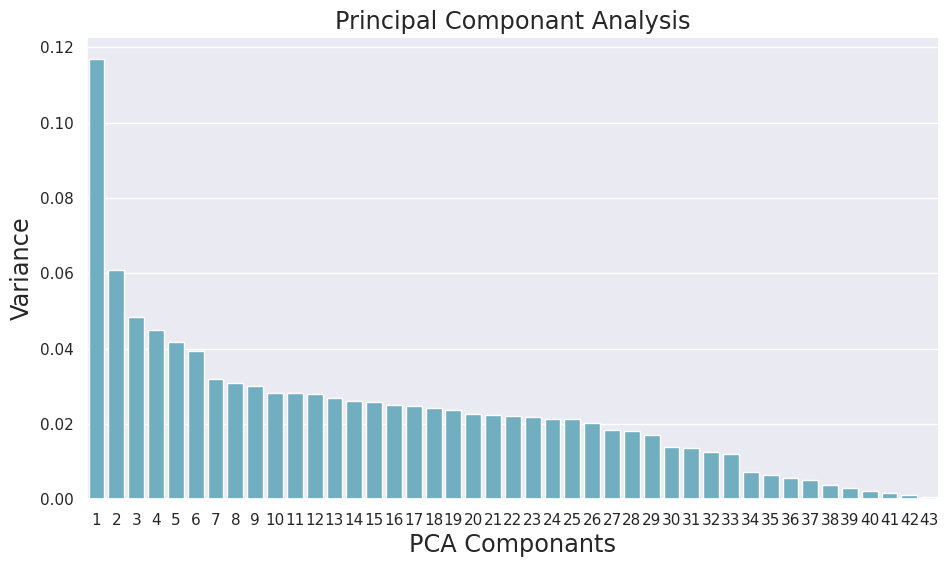

In [ ]:
df_pca = pd.DataFrame({'var':explained_variance,
             'PC':list(range(1,44))})
fig = plt.figure(figsize=(11,6))
fig=sns.barplot(x = 'PC', y = "var", data = df_pca, color = "c")
plt.xlabel('PCA Componants', fontsize = 'x-large')
plt.ylabel('Variance', fontsize = 'x-large')
plt.title('Principal Componant Analysis', fontsize = 'x-large')
plt.show()

In [ ]:
df_cumus = pd.DataFrame({'total_var':np.cumsum(df_pca['var'].values)})
df_cumus

,total_var
0,0.116827
1,0.177635
2,0.226009
3,0.270974
4,0.312647
5,0.352041
6,0.383993
7,0.414746
8,0.444805
9,0.473129


## 3. Applying Machine Learning # Algorithms

**Classification Function with All Features**

In [ ]:
def classification_all_features(Model):
    """
    This function apply machine learning algorithms into the all features in the dataset and
    returns confusion matrix and f1 score which will be used in models comparison.
    """

    # Separate response variable and features
    X = df4.iloc[:, :-1].values
    y = df4.iloc[:, 43].values

    # Splitting the dataset into the Training set and Test set
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

    # Feature Scaling
    sc_X = StandardScaler()
    X_train = sc_X.fit_transform(X_train)
    X_test = sc_X.transform(X_test)

    # Instantiate the classifier: model
    model = Model

    # Fitting classifier to the Training set (all features)
    model.fit(X_train, y_train)

    # Predicting the Test set results
    y_pred = model.predict(X_test)

    global score
    # Assign f1 score to a variable
    score = f1_score(y_test, y_pred, average = 'weighted')

    # Printing evaluation metric (f1-score)
    print("f1 score: {}".format(score))

    # Making the Confusion Matrix
    print(confusion_matrix(y_test, y_pred))

**Classification Function with Hyperparameter Tuning (all features)**

In [ ]:
def classification_tuning_all(regularizator):
    """
    This function apply hyperparameter tuning to machine learning algorithms with all features and
    returns best parameters, confusion matrix and f1 score which will be used in models comparison.
    """

    # Separate response variable and features
    X = df4.iloc[:, :-1].values
    y = df4.iloc[:, 43].values

    # Splitting the dataset into the Training set and Test set
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

    # Feature Scaling
    sc_X = StandardScaler()
    X_train = sc_X.fit_transform(X_train)
    X_test = sc_X.transform(X_test)

    # Hyperparameter with regularizator
    model_cv = regularizator

    # Fitting classifier to the Training set (all features)
    model_cv.fit(X_train, y_train)

    # Predicting the Test set results
    y_pred = model_cv.predict(X_test)

    global score
    # Assign f1 score to a variable
    score = model_cv.score(X_test, y_test)
    #score = f1_score(y_test, y_pred, average='weighted')

    # Printing evaluation metric (f1-score)
    print("f1 score: {}".format(score))

    # Printing Tuned Model Parameters
    print("Tuned Model Parameters: {}".format(model_cv.best_params_))

    # Making the Confusion Matrix
    print(confusion_matrix(y_test, y_pred))

**Classification Function with Principal Component Analysis(PCA) Features**

In [ ]:
def classification_pca_features(Model):
    """
    This function apply machine learning algorithms into the all PCA features and
    returns confusion matrix and f1 score which will be used in models comparison.
    """

    # Separate response variable and features
    X = df4.iloc[:, :-1].values
    y = df4.iloc[:, 43].values

    # Splitting the dataset into the Training set and Test set
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

    # Feature Scaling
    sc_X = StandardScaler()
    X_train = sc_X.fit_transform(X_train)
    X_test = sc_X.transform(X_test)

    # Extracting 27 features from PCA
    pca = PCA(n_components = 27)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # Instantiate the classifier: model
    model = Model

    # Fitting classifier to the Training set (all features)
    model.fit(X_train_pca, y_train)

    # Predicting the Test set results
    y_pred = model.predict(X_test_pca)

    global score
    # Assign f1 score to a variable
    score = f1_score(y_test, y_pred, average = 'weighted')

    # Printing evaluation metric (f1-score)
    print("f1 score: {}".format(score))

    # Making the Confusion Matrix
    print(confusion_matrix(y_test, y_pred))

**Classification Function with Hyperparameter Tuning with PCA features**

In [ ]:
def classification_tuning_pca(regularizator):
    """
    This function apply hyperparameter tuning to machine learning algorithms with pca features and
    returns best parameters, confusion matrix and f1 score which will be used in models comparison.
    """

    # Separate response variable and features
    X = df4.iloc[:, :-1].values
    y = df4.iloc[:, 43].values

    # Splitting the dataset into the Training set and Test set
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

    # Feature Scaling
    sc_X = StandardScaler()
    X_train = sc_X.fit_transform(X_train)
    X_test = sc_X.transform(X_test)

    # Extracting 27 features from PCA
    pca = PCA(n_components = 27)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # Hyperparameter with regularizator
    model_cv = regularizator

    # Fitting classifier to the Training set (all features)
    model_cv.fit(X_train_pca, y_train)

    # Predicting the Test set results
    y_pred = model_cv.predict(X_test_pca)

    global score
    # Assign f1 score to a variable
    score = model_cv.score(X_test_pca, y_test)

    # Printing evaluation metric (f1-score)
    print("f1 score: {}".format(score))

    # Printing Tuned Model Parameters
    print("Tuned Model Parameters: {}".format(model_cv.best_params_))

    # Making the Confusion Matrix
    print(confusion_matrix(y_test, y_pred))

### 4.1 - Logistic Regression

In [ ]:
# Function for logistic regression with all features
classification_all_features(LogisticRegression(random_state = 0))

In [ ]:
# Assign f1 score to a variable for the model comparison
lrg1 = score

In [ ]:
# Set up parameters
param_grid = {'C': np.arange(1, 1000)}

# Function for hyperparameter tuning to logistic regression with all features
classification_tuning_all(GridSearchCV(LogisticRegression(random_state = 0),
                                       param_grid, cv=5, scoring = 'f1_weighted'))

In [ ]:
# Assign f1 score to a variable for the model comparison
lrg2 = score

In [ ]:
# Function for logistic regression with PCA features
classification_pca_features(LogisticRegression(random_state = 0))

In [ ]:
# Assign f1 score to a variable for the model comparison
lrg3 = score

In [ ]:
# Set up parameters
param_grid={'C': np.arange(1, 1000)}

# Functions for tuning logistic regression with pca features
classification_tuning_pca(GridSearchCV(LogisticRegression(random_state = 0),
                                       param_grid, cv = 5, scoring = 'f1_weighted'))

In [ ]:
# Assign f1 score to a variable for the model comparison
lrg4 = score

### 4.2 - Decision Tree Classification

In [ ]:
# Function for decision tree classification model with all features
classification_all_features(DecisionTreeClassifier(criterion = 'gini', random_state = 0))

In [ ]:
# Assign f1 score to a variable for the model comparison
dtr1 = score

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score
from scipy.stats import randint
import numpy as np

# Setup the parameters and distributions to sample from: param_dist
param_dist = {"max_depth": np.linspace(1, 33),
              "min_samples_leaf": randint(1, 9),
              "criterion": ["gini", "entropy"]}

# Function for hyperparameter tuning to decision tree classification with all features
classification_tuning_all(RandomizedSearchCV(DecisionTreeClassifier(random_state = 0),
                                             param_dist, cv=5, scoring = 'f1_weighted'))

In [ ]:
# Assign f1 score to a variable for the model comparison
dtr2 = score

In [ ]:
# Function for decision tree classification with PCA features
classification_pca_features(DecisionTreeClassifier())

In [ ]:
# Assign f1 score to a variable for the model comparison
dtr3 = score

In [ ]:
# Setup the parameters and distributions to sample from: param_dist
param_dist = {"max_depth": np.linspace(1, 32, 32, endpoint = True),
              "min_samples_leaf": randint(1, 9),
              "criterion": ["gini", "entropy"]}

# Functions for tuning decision trees with pca features
classification_tuning_pca(RandomizedSearchCV(DecisionTreeClassifier(),
                                             param_dist, cv = 5, scoring = 'f1_weighted', random_state = 0))

In [ ]:
# Assign f1 score to a variable for the model comparison
dtr4 = score

### 4.3 - Random Forest Classification

In [ ]:
# Function for Random Forest Classification model with all features
classification_all_features(RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0))

In [ ]:
# Assign f1 score to a variable for model comparison
rfc1 = score

In [ ]:
# Setup the parameters and distributions to sample from: param_dist
n_estimators = [int(x) for x in np.linspace(start = 10, stop = 2000, num = 10)]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4]

random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf}

# Function for hyperparameter tuning to random forest classification with all features
classification_tuning_all(RandomizedSearchCV(estimator = RandomForestClassifier(random_state = 0),
                                             param_distributions = random_grid, n_iter = 100, cv = 5,
                                             verbose=2, random_state=0, n_jobs = -1, scoring = 'f1_weighted'))

In [ ]:
# Assign f1 score to a variable for model comparison
rfc2 = score

In [ ]:
# Function for Random Forest Classification with PCA features
classification_pca_features(RandomForestClassifier(random_state=0))

In [ ]:
# Assign f1 score to a variable for the model comparison
rfc3 = score

#### 4.3.4 - Random Forest with Hyperparameter Tuning (PCA features)

In [ ]:
# Seting up parameters
n_estimators = [int(x) for x in np.linspace(start = 10, stop = 2000, num = 10)]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4]

random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf}

# Functions for tuning Random Forest classification with pca features
classification_tuning_pca(RandomizedSearchCV(estimator = RandomForestClassifier(), param_distributions = random_grid,
                                             n_iter = 100, cv = 5, verbose=2, random_state=0, n_jobs = -1,
                                             scoring = 'f1_weighted'))

In [ ]:
# Assign f1 score to a variable for the model comparison
rfc4 = score

### 4.4 - K-NN Classification

In [ ]:
# Function for K-NN classification with all features
classification_all_features(KNeighborsClassifier())

In [ ]:
# Assign f1 score to a variable for the model comparison
knn1 = score

In [ ]:
# Set up parameters
param_grid={'n_neighbors': np.arange(1, 50)}

# Function for hyperparameter tuning to K-NN classification with all features
classification_tuning_all(GridSearchCV(KNeighborsClassifier(),
                                       param_grid, cv = 5, scoring = 'f1_weighted'))

In [ ]:
# Assign f1 score to a variable for the model comparison
knn2 = score

In [ ]:
# Function for K-NN Classification with PCA features
classification_pca_features(KNeighborsClassifier())

In [ ]:
# Assign f1 score to a variable for the model comparison
knn3 = score

In [ ]:
# Setting up parameters
param_grid={'n_neighbors': np.arange(1, 50)}

# Functions for tuning K-NN classification with pca features
classification_tuning_pca(GridSearchCV(KNeighborsClassifier(), param_grid,
                                       cv = 5, scoring = 'f1_weighted'))

In [ ]:
# Assign f1 score to a variable for the model comparison
knn4 = score

### 4.5 - Support Vector Machine(SVM) Classification

In [ ]:
# Function for SVM classifier with all features
classification_all_features(SVC(kernel = 'linear', random_state = 0))

In [ ]:
# Assign f1 score to a variable for the model comparison
svm1 = score

In [ ]:
# Specify the hyperparameter space
Cs = [0.001, 0.01, 0.1, 1, 10]
gammas = [0.001, 0.01, 0.1, 1]
param_grid = {'C': Cs, 'gamma' : gammas}

# Function for hyperparameter tuning to SVM classification with all features
classification_tuning_all(GridSearchCV(SVC(kernel='linear'), param_grid,
                                       cv = 5, scoring = 'f1_weighted'))

In [ ]:
# Assign f1 score to a variable for the model comparison
svm2 = score

In [ ]:
# Function for SVM classification with PCA features
classification_pca_features(SVC())

In [ ]:
# Assign f1 score to a variable for the model comparison
svm3 = score

In [ ]:
# Specify the hyperparameter space
Cs = [0.001, 0.01, 0.1, 1, 10]
gammas = [0.001, 0.01, 0.1, 1]
param_grid = {'C': Cs, 'gamma' : gammas}

# Functions for tuning SVM classification with pca features
classification_tuning_pca(GridSearchCV(SVC(kernel='linear'), param_grid,
                                       cv=5, scoring = 'f1_weighted'))

In [ ]:
# Assign f1 score to a variable for the model comparison
svm4 = score

### 4.6 - Kernel Support Vector Machine(SVM) Classification

In [ ]:
# Function for Kernal SVM classifier with all features
classification_all_features(SVC(kernel = 'rbf', random_state = 0))

In [ ]:
# Assign f1 score to a variable for the model comparison
ksvm1 = score

In [ ]:
# Specify the hyperparameter space
Cs = [0.001, 0.01, 0.1, 1, 10]
gammas = [0.001, 0.01, 0.1, 1]
param_grid = {'C': Cs, 'gamma' : gammas}

# Function for hyperparameter tuning to Kernel SVM classification with all features
classification_tuning_all(GridSearchCV(SVC(kernel='rbf'), param_grid,
                                       cv=5, scoring = 'f1_weighted'))

In [ ]:
# Assign f1 score to a variable for the model comparison
ksvm2 = score

In [ ]:
# Function for Kernel SVM classification with PCA features
classification_pca_features(SVC(kernel='rbf'))

In [ ]:
# Assign f1 score to a variable for the model comparison
ksvm3 = score

In [ ]:
# Specify the hyperparameter space
Cs = [0.001, 0.01, 0.1, 1, 10]
gammas = [0.001, 0.01, 0.1, 1]
param_grid = {'C': Cs, 'gamma' : gammas}

# Functions for tuning SVM classification with pca features
classification_tuning_pca(GridSearchCV(SVC(kernel='rbf'), param_grid,
                                       cv = 5, scoring = 'f1_weighted'))

In [ ]:
# Assign f1 score to a variable for the model comparison
ksvm4 = score

### 4.7 - Naive Bayes Classification

In [ ]:
# Function for Naive Bayes Classifier with all features
classification_all_features(GaussianNB())

In [ ]:
# Assign f1 score to a variable for the model comparison
nb1 = score

In [ ]:
# Function for Naive Bayes Classification with PCA features
classification_pca_features(GaussianNB())

In [ ]:
# Assign f1 score to a variable for the model comparison
nb2 = score

### 4-8 Gradient Boosting Classification

In [ ]:
# Function for Gradient Boosting Classifier with all features
classification_all_features(GradientBoostingClassifier())

In [ ]:
# Assign f1 score to a variable for the model comparison
gb1 = score

In [ ]:
# Setting Parameters
gb_params ={
    'n_estimators': 1500,
    'max_features': 0.9,
    'learning_rate' : 0.25,
    'max_depth': 2,
    'min_samples_leaf': 3,
    'subsample': 1,
    'max_features' : 'sqrt',
    'random_state' : 0
}

# Instantiate Gradient Boosting classifier: gb
gb = GradientBoostingClassifier(**gb_params)

# Fit to the training set
gb.fit(X_train, y_train)

# Predict the labels of the test set: y_pred
y_pred = gb.predict(X_test)

# Assigning f1 score to a variable
gb2 = f1_score(y_test, y_pred, average = 'weighted')

# Printing evaluation metric (f1-score)
print(gb2)

# Making the Confusion Matrix
confusion_matrix(y_test, y_pred)

In [ ]:
# Function for Gradient Boosting Classification with PCA features
classification_pca_features(GradientBoostingClassifier())

In [ ]:
# Assign f1 score to a variable for the model comparison
gb3 = score

In [ ]:
# Separate response variable and features
X = df3.iloc[:, :-1].values
y = df3.iloc[:, 43].values

# Splitting the dataset into the Training set and Test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

# Feature Scaling
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

# Extracting 27 features from PCA
pca = PCA(n_components = 27)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Gradient Boosting Parameters
gb_params ={
    'n_estimators': 1500,
    'max_features': 0.9,
    'learning_rate' : 0.25,
    'max_depth': 2,
    'min_samples_leaf': 3,
    'subsample': 1,
    'max_features' : 'sqrt',
    'random_state' : 0
}

# Instantiate Gradient Boosting classifier: gb
gb = GradientBoostingClassifier(**gb_params)

# Fit to the training set
gb.fit(X_train_pca, y_train)

# Predict the labels of the test set: y_pred
y_pred = gb.predict(X_test_pca)

# Assign f1 score to a variable for the model comparison
gb4 = f1_score(y_test, y_pred, average = 'weighted')

# Printing evaluation metric (f1-score)
print(gb4)

# Making the Confusion Matrix
confusion_matrix(y_test, y_pred)

### 4.9 - ADA Boost Classification

In [ ]:
# Function for ADA Boost Classifier with all features
classification_all_features(AdaBoostClassifier())

In [ ]:
ada1 = score

In [ ]:
# Instantiate ADA Boosting classifier: abc
abc = AdaBoostClassifier(n_estimators= 150, learning_rate = 0.2, random_state = 0)

# Fitting ADA Boosting classification to the Training set
abc.fit(X_train, y_train)

# Predict the labels of the test set: y_pred
y_pred = abc.predict(X_test)

# Printing evaluation metric (f1-score)
print(f1_score(y_test, y_pred, average = 'weighted'))

# Making the Confusion Matrix
confusion_matrix(y_test, y_pred)

In [ ]:
# Assign f1 score to a variable for the model comparison
ada2 = score

In [ ]:
# Function for ADA Boost Classification with PCA features
classification_pca_features(AdaBoostClassifier())

In [ ]:
# Assign f1 score to a variable for the model comparison
ada3 = score

In [ ]:
# Separate response variable and features
X = df3.iloc[:, :-1].values
y = df3.iloc[:, 43].values

# Splitting the dataset into the Training set and Test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

# Feature Scaling
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

# Extracting 27 features from PCA
pca = PCA(n_components = 27)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Instantiate ADA Boosting classifier: abc
abc = AdaBoostClassifier(n_estimators= 250, learning_rate = 0.25, random_state = 0)

# Fitting ADA Boosting classification to the Training set
abc.fit(X_train_pca, y_train)

# Predict the labels of the test set: y_pred
y_pred = abc.predict(X_test_pca)

# Assign f1 score to a variable
ada4 = f1_score(y_test, y_pred, average = 'weighted')

# Printing evaluation metric (f1-score)
print(ada4)

# Making the Confusion Matrix
confusion_matrix(y_test, y_pred)

## 5. Model Comparison

In [ ]:
# Dictionary of model f1 scores to compare
results={'Logistic Regression': [lrg1, lrg2, lrg3, lrg4],
         'Decision Tree': [dtr1, dtr2, dtr3, dtr4],
         'Random Forest': [rfc1, rfc2, rfc3, rfc4],
         'K-NN': [knn1, knn2, knn3, knn4],
         'SVM': [svm1, svm2, svm3, svm4],
         'Kernel SVM': [ksvm1, ksvm2, ksvm3, ksvm4],
         'Naive Bayes': [nb1, nb1, nb2, nb2],
         'Gradient Boosting': [gb1, gb2, gb3, gb4],
         'ADA Boosting': [ada1, ada2, ada3, ada4]}

In [ ]:
# Creating model comparison dataframe
comparison = pd.DataFrame.from_dict(results, orient='index')
comparison.columns = ['all_features', 'tuned_all_features', 'PCA_features', 'tuned_PCA_features']

In [ ]:
# Computing the total improvement on the f1 score

list1 = []
for i in comparison.index:
    d = max(comparison.all_features[i], comparison.tuned_all_features[i], comparison.PCA_features[i], comparison.tuned_PCA_features[i])
    e = (d / comparison.all_features[i]) - 1
    list1.append(float("%.4f" % e))

comparison['Total Improvement(%)'] = list1

In [ ]:
# Models Compare List
comparison

,all_features,tuned_all_features,PCA_features,tuned_PCA_features,Total Improvement(%)
Logistic Regression,0.875442,0.875442,0.843742,0.843742,0.0000
Decision Tree,0.790452,0.792969,0.788889,0.804466,0.0177
Random Forest,0.826190,0.845914,0.804907,0.812311,0.0239
K-NN,0.829883,0.810444,0.815210,0.815783,0.0000
SVM,0.869366,0.881111,0.823034,0.845970,0.0135
Kernel SVM,0.845668,0.849900,0.823034,0.845450,0.0050
Naive Bayes,0.699065,0.699065,0.825964,0.825964,0.1815
Gradient Boosting,0.864627,0.866205,0.823078,0.838986,0.0018
ADA Boosting,0.852034,0.852034,0.874469,0.847921,0.0263


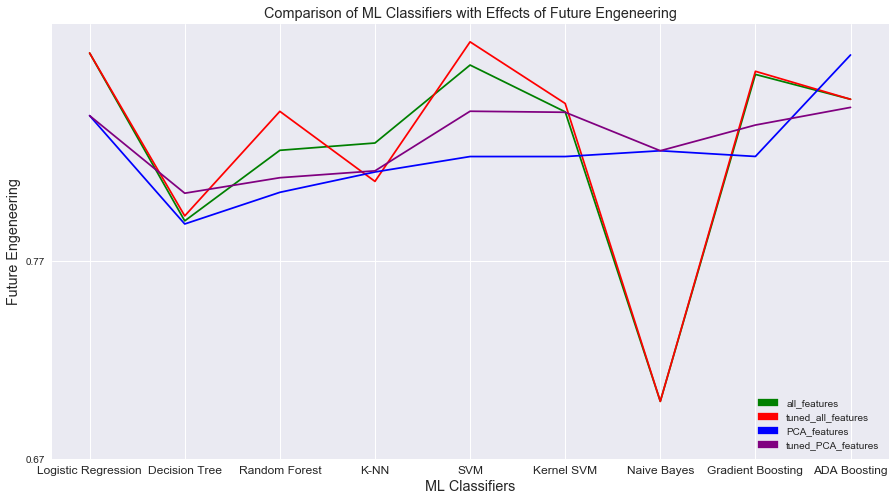

In [ ]:
# Comparison of ML Classifiers with Effects of Feature Engineering
import matplotlib.patches as mpatches

r = [0,1,2,3,4,5,6,7,8]

# From raw value to percentage
A = comparison.iloc[:,0]
B = comparison.iloc[:,1]
C = comparison.iloc[:,2]
D = comparison.iloc[:,3]

# plot
barWidth = 0.85
names = ('Logistic Regression', 'Decision Tree', 'Random Forest', 'K-NN', 'SVM',
         'Kernel SVM', 'Naive Bayes', 'Gradient Boosting', 'ADA Boosting')
fig = plt.figure(figsize=(15,8))

# Create green Bars
plt.plot(r, A, color='green')

# Create orange Bars
plt.plot(r, B, color='red')

# Create blue Bars
plt.plot(r, C, color='blue')

# Create purple Bars
plt.plot(r, D, color='purple')

# Custom x axis
plt.xticks(r, names, fontsize='large')
plt.yticks(np.arange(0.67,0.78,0.1))
plt.xlabel("ML Classifiers", fontsize='x-large')
plt.ylabel("Future Engeneering", fontsize='x-large')
plt.title("Comparison of ML Classifiers with Effects of Future Engeneering", fontsize='x-large')

green = mpatches.Patch(color='green', label='all_features')
orange = mpatches.Patch(color='red', label='tuned_all_features')
blue = mpatches.Patch(color='blue', label='PCA_features')
purple = mpatches.Patch(color='purple', label='tuned_PCA_features')
plt.legend(handles=[green, orange, blue, purple], loc=4)

# Show graphic
plt.show()

In [ ]:
# Specify the hyperparameter space
Cs = [0.001, 0.01, 0.1, 1, 10]
gammas = [0.001, 0.01, 0.1, 1]
param_grid = {'C': Cs, 'gamma' : gammas}

# Instantiate Support Vector Machine classifier: svm
svm = SVC(kernel='linear')

svm_cv = GridSearchCV(svm, param_grid, cv=5, scoring = 'f1_weighted')

# Fit to the training set
svm_cv.fit(X_train_sm, y_train_sm)

# Predict the labels of the test set: y_pred
y_pred = svm_cv.predict(X_test)

# Compute and print metrics
print("f1 score: {}".format(svm_cv.score(X_test, y_test)))
print("Tuned Model Parameters: {}".format(svm_cv.best_params_))

In [ ]:
# Coefficients of feature importance (values for dictionary)
svr = SVC(kernel='linear', C = 0.1, gamma = 0.001)
clf = svr.fit(X_train, y_train)
clfc = clf.coef_

In [ ]:
value = reduce(lambda x, y: x+y, clfc)
values = [x for x in value]
values

[-1.4746034447649103e-05,
 2.0601761914679217e-05,
 4.611157128268234e-05,
 -1.2010143531637762e-06,
 -3.405620315477531e-06,
 7.494825538190142e-06,
 1.8022937581602116e-05,
 -0.00010576040184719082,
 1.0383074789288571e-05,
 7.930734174182996e-05,
 -1.7103946593988173e-05,
 2.9811332159943027e-05,
 -2.1755289172767367e-05,
 -1.945536009457377e-05,
 1.518226153129909e-06,
 -2.767464240605033e-05,
 -7.332459138975622e-06,
 7.130445545011632e-06,
 3.337379892857234e-05,
 -1.9023548915524102e-05,
 6.773579275226593e-06,
 1.571222844040654e-05,
 2.3643917374444046e-05,
 1.8300583506325463e-05,
 9.038893388230163e-05,
 9.680158105224157e-05,
 -0.00010590065730942122,
 -6.13739073935804e-05,
 -7.258782444724554e-05,
 -4.0137996320549485e-05,
 -7.574033798685154e-05,
 1.7840803214666523e-05,
 -2.190204412400032e-05,
 -9.569121505512146e-05,
 -2.276698943959321e-05,
 -1.497393398097735e-05,
 8.177293386646411e-06,
 -9.28230991421447e-05,
 -0.00010127647494062586,
 -7.194191725279353e-05,
 2.0

In [ ]:
df4 = df3.drop('Attrition', axis =1)

In [ ]:
# Dictionary for feature importance - keys and values
idx = df4.columns
keys = [str(x) for x in idx.tolist()]
pairs = {keys[i]: values[i] for i in range(len(keys))}

In [ ]:
pairs

{'Age': -1.4746034447649103e-05,
 'BusinessTravel': 2.0601761914679217e-05,
 'DailyRate': 4.611157128268234e-05,
 'Department': -1.2010143531637762e-06,
 'DistanceFromHome': -3.405620315477531e-06,
 'Education': 7.494825538190142e-06,
 'EducationField': 1.8022937581602116e-05,
 'EnvironmentSatisfaction': -0.00010576040184719082,
 'Gender': 1.0383074789288571e-05,
 'HourlyRate': 7.930734174182996e-05,
 'JobInvolvement': -1.7103946593988173e-05,
 'JobLevel': 2.9811332159943027e-05,
 'JobRole': -2.1755289172767367e-05,
 'JobSatisfaction': -1.945536009457377e-05,
 'MaritalStatus': 1.518226153129909e-06,
 'MonthlyIncome': -2.767464240605033e-05,
 'MonthlyRate': -7.332459138975622e-06,
 'NumCompaniesWorked': 7.130445545011632e-06,
 'OverTime': 3.337379892857234e-05,
 'PercentSalaryHike': -1.9023548915524102e-05,
 'RelationshipSatisfaction': 6.773579275226593e-06,
 'StockOptionLevel': 1.571222844040654e-05,
 'TotalWorkingYears': 2.3643917374444046e-05,
 'TrainingTimesLastYear': 1.830058350632

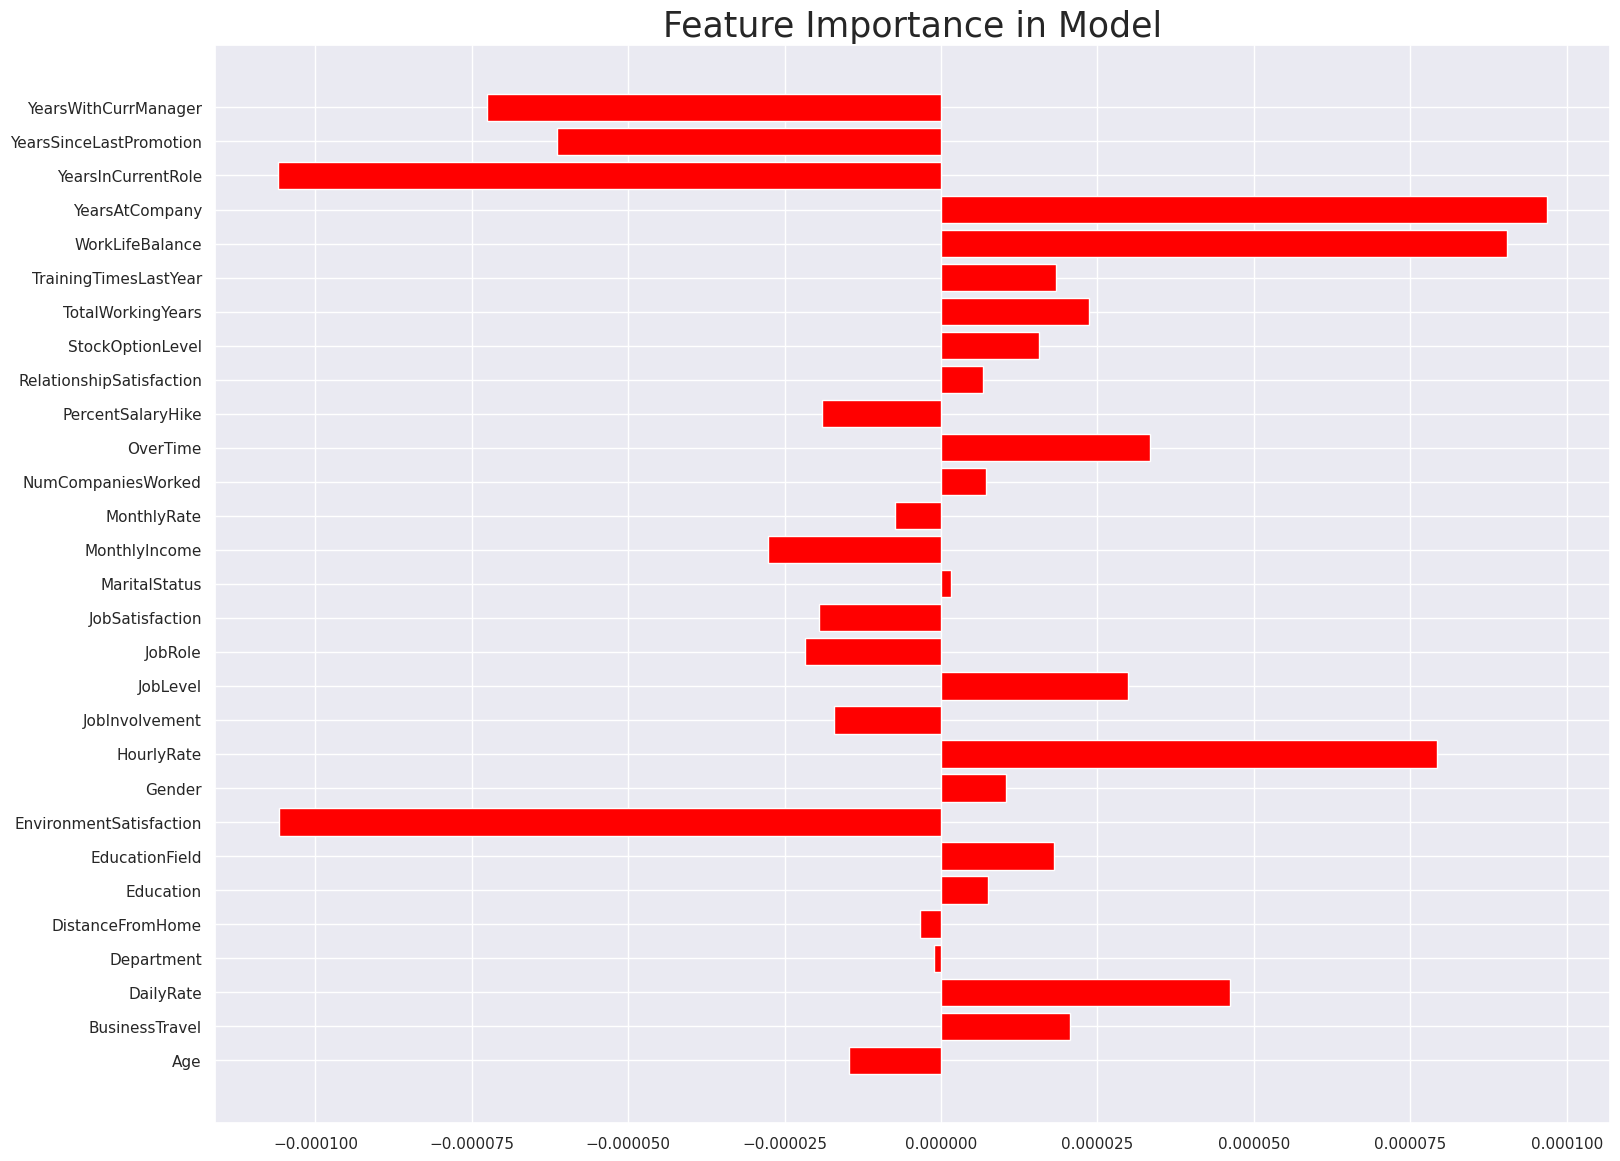

In [ ]:
# Plotting feature importance for SVM model
names = list(pairs.keys())
values = list(pairs.values())

plt.figure(figsize=(18,14))
plt.barh(range(len(pairs)), values, tick_label = names, color = 'red')
plt.title('Feature Importance in Model', fontsize = 25)
plt.show()